In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = './'

print("Đang load dữ liệu...")
orders      = pd.read_csv(DATA_DIR + 'orders.csv',      parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
payments    = pd.read_csv(DATA_DIR + 'payments.csv')
returns     = pd.read_csv(DATA_DIR + 'returns.csv',     parse_dates=['return_date'])
reviews     = pd.read_csv(DATA_DIR + 'reviews.csv',     parse_dates=['review_date'])
sales       = pd.read_csv(DATA_DIR + 'sales.csv',       parse_dates=['Date'])
customers   = pd.read_csv(DATA_DIR + 'customers.csv')
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv')
products    = pd.read_csv(DATA_DIR + 'products.csv')
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv')
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')
geography   = pd.read_csv(DATA_DIR + 'geography.csv')
print("Load xong!\n")

# Pre-compute shared columns
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

order_items['line_rev'] = (order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount'])
order_items['has_promo'] = order_items['promo_id'].notna()

sales['year']   = sales['Date'].dt.year
sales['month']  = sales['Date'].dt.month
sales['profit'] = sales['Revenue'] - sales['COGS']
sales['margin'] = (sales['profit'] / sales['Revenue'] * 100).clip(-50, 50)


Đang load dữ liệu...
Load xong!



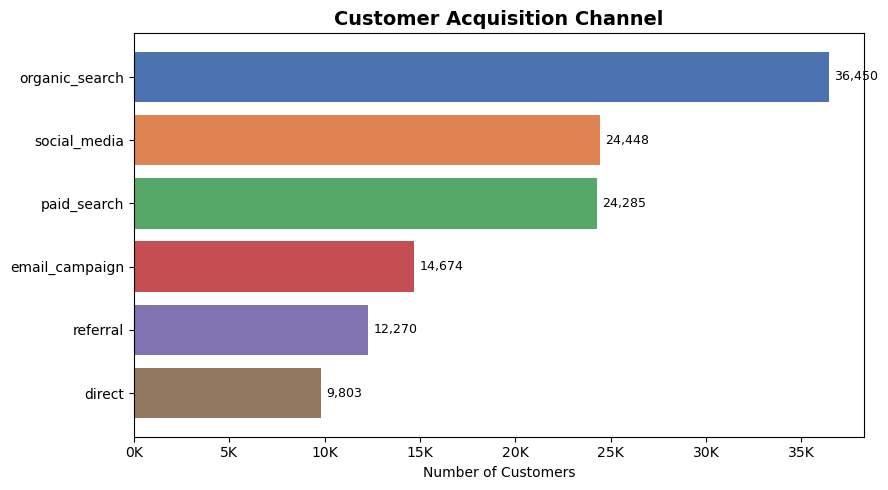

In [2]:
# Chart 1: Customer Acquisition Channel
fig, ax = plt.subplots(figsize=(9, 5))
acq = customers['acquisition_channel'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
bars = ax.barh(acq.index, acq.values, color=colors)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_title('Customer Acquisition Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

**Overview:** Biểu đồ cột ngang thể hiện số lượng khách hàng được thu hút qua 6 kênh khác nhau, giúp xác định kênh nào đang hoạt động hiệu quả nhất trong việc mở rộng tệp khách hàng.

**Descriptive - What happened?**
Tổng cộng 121.930 khách hàng được thu hút qua 6 kênh. Organic search dẫn đầu với 36.450 khách (29,9%), tiếp theo là social media (24.448 — 20,1%) và paid search (24.285 — 19,9%). Direct là kênh yếu nhất với chỉ 9.803 khách (8,0%).

**Diagnostic - Why did it happen?**
Organic search chiếm gần 30% cho thấy thương hiệu đã xây dựng được độ nhận diện tự nhiên tốt. Social media và paid search gần bằng nhau (~20% mỗi kênh), phản ánh chi phí quảng cáo đang song song với tăng trưởng tự nhiên. Kênh referral (10,1%) thấp hơn kỳ vọng, cho thấy chương trình giới thiệu bạn bè chưa được khai thác hiệu quả.

**Predictive - What is likely to happen?**
Dữ liệu theo năm cho thấy social media tăng trưởng nhanh nhất (+62% từ 2018–2022). Xu hướng này cho thấy social media sẽ vượt qua organic search trong 2–3 năm tới nếu không có đầu tư thêm vào SEO. Email campaign cũng tăng đều (~66% trong 5 năm), cho thấy kênh này ngày càng hiệu quả hơn.

**Prescriptive - What should we do?**
Tăng ngân sách SEO content để duy trì vị trí dẫn đầu của organic search trước khi bị social media vượt qua.
Xây dựng chương trình referral bằng cách tặng voucher cho cả người giới thiệu lẫn người được giới thiệu — chi phí thấp nhưng tiềm năng nhân đôi lượng khách.
Tối ưu email campaign: với 14.674 khách từ email, cần A/B test subject line và thời điểm gửi để cải thiện conversion rate.

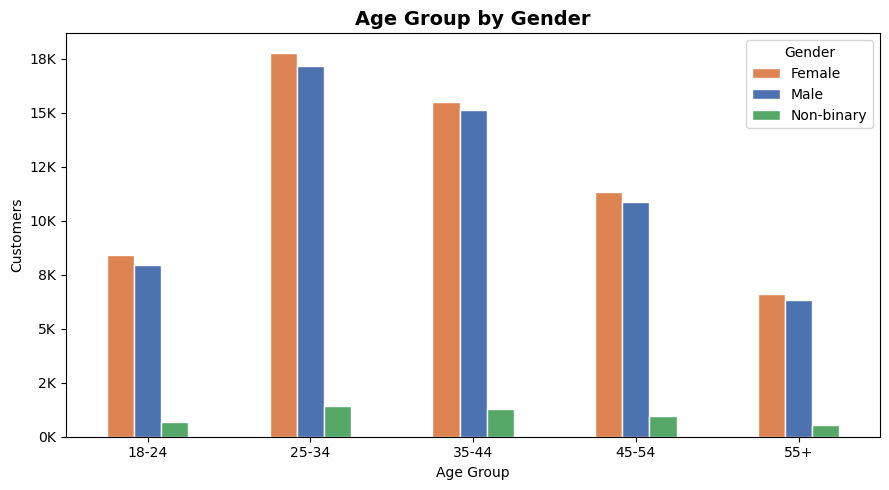

In [3]:
# Chart 2: Age group by Gender
fig, ax = plt.subplots(figsize=(9, 5))
age_gender = customers.groupby(['age_group', 'gender']).size().unstack(fill_value=0)
age_gender = age_gender.reindex(['18-24', '25-34', '35-44', '45-54', '55+'])
age_gender.plot(kind='bar', ax=ax, color=['#DD8452', '#4C72B0', '#55A868'], edgecolor='white')
ax.set_title('Age Group by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Customers')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Gender')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

**Overview:** Biểu đồ cột nhóm so sánh phân bổ khách hàng theo nhóm tuổi và giới tính, giúp hiểu rõ chân dung khách hàng mục tiêu và phát hiện các phân khúc chưa được khai thác.

**Descriptive - What happened?**
Nhóm tuổi 25–34 chiếm đông nhất (36.342 khách — 29,8%), tiếp theo là 35–44 (31.920 — 26,2%). Nhóm 55+ nhỏ nhất với 13.457 khách (11,0%). Tỷ lệ giới tính gần như đồng đều ở tất cả nhóm tuổi: Female ~49%, Male ~47%, Non-binary ~4%.

**Diagnostic - Why did it happen?**
Sự tập trung ở nhóm 25–44 (tổng 56%) phù hợp với danh mục sản phẩm (Streetwear, GenZ, Casual, Outdoor) — đây là nhóm có thu nhập ổn định và quan tâm đến thời trang. Tỷ lệ non-binary nhất quán (~4%) ở mọi nhóm tuổi cho thấy đây là đặc điểm ổn định của tập khách hàng, không phải xu hướng thế hệ.

**Predictive - What is likely to happen?**
Nhóm 18–24 (GenZ thực tế) chiếm 14% — tương đối thấp nhưng đang trong giai đoạn xây dựng thói quen mua sắm. Nếu không có chiến lược giữ chân, nhóm này sẽ chuyển sang đối thủ. Nhóm 35–44 sẽ già đi thành 45–54 và nhu cầu sản phẩm của họ sẽ thay đổi theo.

**Prescriptive - What should we do?**
Tạo sản phẩm/chiến dịch riêng cho GenZ (18–24): hiện danh mục "GenZ" chỉ có 148 sản phẩm (ít nhất), cần mở rộng thêm.
Upsell cho nhóm 25–34: đây là tệp lớn nhất — nên áp dụng loyalty program và bundle deals.
Không bỏ qua nhóm 45–54 và 55+ (tổng 30%): họ thường có giá trị đơn hàng cao hơn — cần thiết kế sản phẩm phù hợp với phong cách lứa tuổi này.

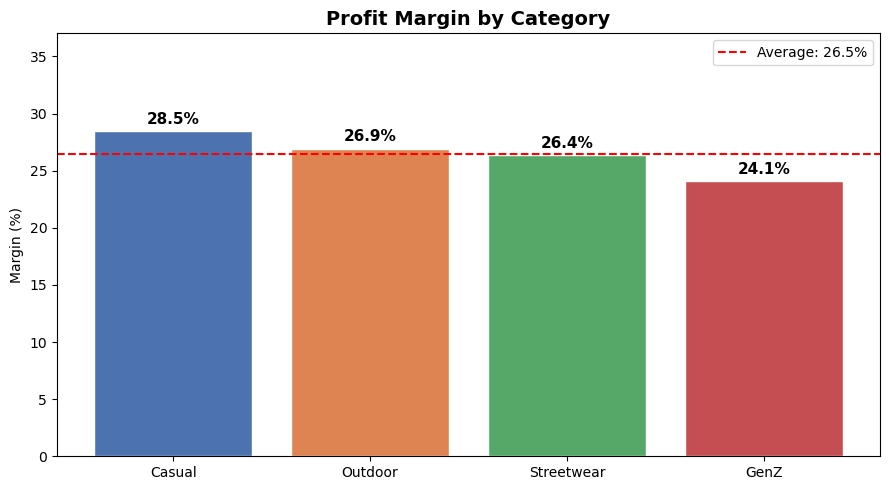

In [4]:
# Chart 3: Profit Margin by Category
fig, ax = plt.subplots(figsize=(9, 5))

margin = products.groupby('category')['margin_pct'].mean().sort_values(ascending=False)
bars = ax.bar(margin.index, margin.values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=11, fontweight='bold')
ax.axhline(margin.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Average: {margin.mean():.1f}%')
ax.set_title('Profit Margin by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Margin (%)')
ax.set_ylim(0, margin.max() * 1.3)
ax.legend()
plt.tight_layout()
plt.show()

**Overview:** Biểu đồ cột thể hiện biên lợi nhuận trung bình (%) của từng danh mục sản phẩm, giúp đánh giá hiệu quả sinh lời và xác định danh mục cần tái cấu trúc giá.

**Descriptive - What happened?**
Casual có margin trung bình cao nhất (28,5%), tiếp theo là Outdoor (26,9%), Streetwear (26,4%), và GenZ thấp nhất (24,1%). Độ lệch chuẩn rất cao ở tất cả danh mục (~14–16%), cho thấy có sự chênh lệch lớn giữa các sản phẩm trong cùng category.

**Diagnostic - Why did it happen?**
GenZ có margin thấp nhất có thể do chiến lược định giá cạnh tranh để thu hút khách hàng trẻ tuổi, hoặc chi phí sản xuất cao hơn do xu hướng vật liệu trendy. Casual có margin cao nhất nhờ sản phẩm đơn giản, chi phí sản xuất thấp. Độ lệch chuẩn lớn (~15%) ở mọi category cho thấy có nhiều sản phẩm "loss leader" đang kéo thấp trung bình.

**Predictive - What is likely to happen?**
Nếu GenZ category tiếp tục tăng trưởng nhưng margin thấp hơn 4,4% so với Casual, tổng lợi nhuận toàn công ty sẽ bị ảnh hưởng khi mix sản phẩm dịch chuyển về GenZ. Cần theo dõi margin theo quý để phát hiện xu hướng sớm.

**Prescriptive - What should we do?**
Review giá sản phẩm GenZ: tăng giá 5–8% có thể đưa margin về ngang Outdoor mà không ảnh hưởng nhiều đến demand nếu brand đủ mạnh.
Phân tích sản phẩm margin thấp (<10%) trong từng category — loại bỏ hoặc tái định giá để nâng trung bình toàn danh mục.
Tập trung marketing vào Casual: margin cao nhất + ít SKU nhất (201) — đây là category có ROI tốt nhất nếu scale up.

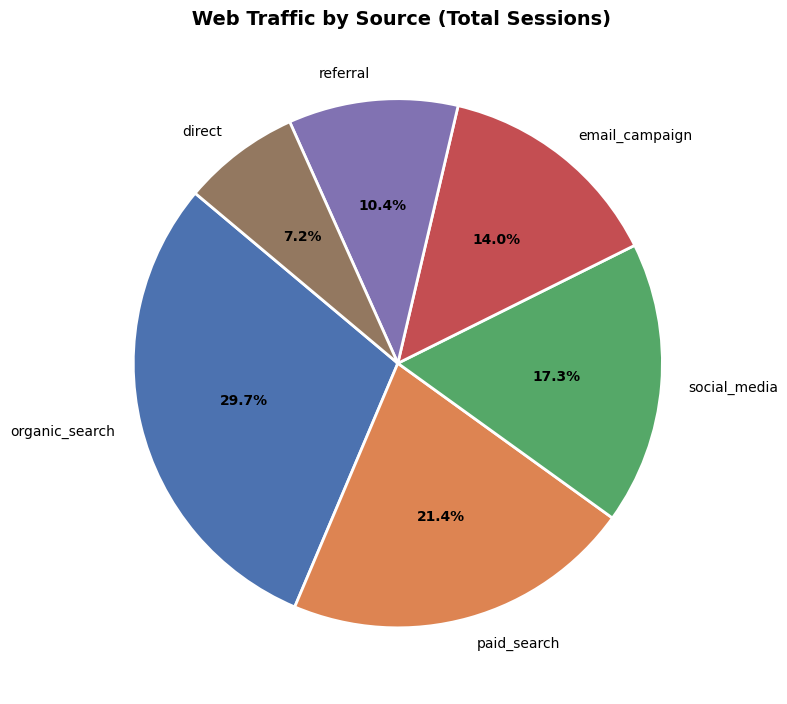

In [5]:
# Chart 4: Traffic Source Distribution
fig, ax = plt.subplots(figsize=(8, 8))

src = web_traffic.groupby('traffic_source')['sessions'].sum().sort_values(ascending=False)
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
wedges, texts, autotexts = ax.pie(
    src.values, labels=src.index, autopct='%1.1f%%',
    colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title(' Web Traffic by Source (Total Sessions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Overview:** Biểu đồ tròn thể hiện tỷ trọng tổng sessions theo từng nguồn traffic, giúp so sánh hiệu quả đóng góp của các kênh digital và định hướng phân bổ ngân sách marketing.

**Descriptive - What happened?**
Organic search chiếm tỷ trọng lớn nhất (29,7% — 27,2 triệu sessions), tiếp theo là paid search (21,4% — 19,6 triệu), social media (17,3% — 15,8 triệu). Direct thấp nhất chỉ 7,2% (6,6 triệu sessions). Tổng cộng ~91,5 triệu sessions trong toàn giai đoạn khảo sát.

**Diagnostic - Why did it happen?**
Organic search dẫn đầu cả về lượng khách hàng (Chart 1) lẫn sessions — SEO là lợi thế cạnh tranh cốt lõi nhất quán. Paid search chiếm 21,4% sessions nhưng chỉ đóng góp 19,9% khách hàng — hiệu suất chuyển đổi thấp hơn organic, gợi ý CAC của kênh này cao hơn. Email campaign chỉ có 13,9% sessions nhưng session duration cao nhất (213s) — kênh nhỏ nhưng chất lượng cao nhất.

**Predictive - What is likely to happen?**
Chi phí paid search đang tăng toàn ngành — nếu không tối ưu, ROI của kênh này sẽ tiếp tục giảm. Referral (10,4%) hiện chưa được khai thác — với chương trình đúng, kênh này có thể tăng gấp đôi mà chi phí thấp hơn paid search nhiều lần.

**Prescriptive - What should we do?**
Tái cân bằng ngân sách: giảm tỷ trọng paid search (CAC cao), tăng đầu tư vào email (chất lượng cao nhất) và referral (tiềm năng cao, chi phí thấp).
Xây dựng referral program chính thức: mục tiêu đưa referral từ 10,4% lên 15–18% trong 12 tháng thông qua incentive cho cả hai phía.
Kết nối dữ liệu sessions với đơn hàng để đo ROI thực sự của từng kênh — biết kênh nào convert tốt nhất mới phân bổ ngân sách chính xác được.

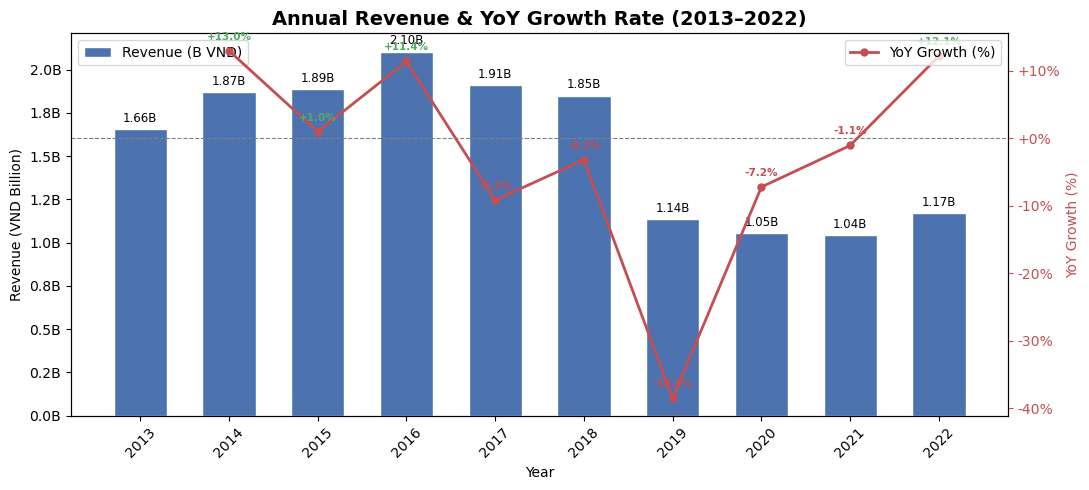

In [6]:
# Chart 5: Annual Revenue & YoY Growth Rate
yoy = (sales[sales['year'] != 2012]
       .groupby('year')['Revenue'].sum()
       .reset_index())
yoy['growth'] = yoy['Revenue'].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = ['#4C72B0'] * len(yoy)
bars = ax.bar(yoy['year'], yoy['Revenue'] / 1e9,
              color=bar_colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='{:.2f}B', padding=3, fontsize=8.5)

ax.set_title('Annual Revenue & YoY Growth Rate (2013–2022)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (VND Billion)')
ax.set_xlabel('Year')
ax.set_xticks(yoy['year'])
ax.set_xticklabels(yoy['year'].astype(int), rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))

ax2 = ax.twinx()
ax2.plot(yoy['year'], yoy['growth'], color='#C44E52',
         lw=2, marker='o', markersize=5, label='YoY Growth (%)')
ax2.axhline(0, color='gray', lw=0.8, linestyle='--')
ax2.set_ylabel('YoY Growth (%)', color='#C44E52')
ax2.tick_params(axis='y', colors='#C44E52')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))

for _, row in yoy.iterrows():
    if pd.notna(row['growth']):
        col = '#55A868' if row['growth'] >= 0 else '#C44E52'
        ax2.annotate(f"{row['growth']:+.1f}%",
            xy=(row['year'], row['growth']),
            xytext=(0, 8), textcoords='offset points',
            ha='center', fontsize=7.5, color=col, fontweight='bold')

ax.legend(['Revenue (B VND)'], loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Overview:** Biểu đồ kết hợp cột (doanh thu tuyệt đối) và đường (tăng trưởng YoY) theo dõi hiệu suất kinh doanh 10 năm, giúp phân biệt giai đoạn tăng trưởng, ổn định và suy giảm của doanh nghiệp.

**Descriptive - What happened?**
Doanh thu tăng trưởng mạnh giai đoạn 2013–2016, đạt đỉnh 2.10B VND vào 2016. Từ 2017 bắt đầu suy giảm với mức giảm mạnh nhất vào 2019 (−38.6%). Giai đoạn 2019–2021 duy trì ở mức thấp ~1.04–1.14B VND. Năm 2022 phục hồi +12.1% lên 1.17B VND.

**Diagnostic - Why did it happen?**
Sụt giảm 2019 (−38.6%) trùng với giai đoạn cạnh tranh thương mại điện tử Việt Nam bùng nổ — Shopee, Lazada đẩy mạnh khuyến mãi lớn, thu hút lượng lớn khách hàng từ các thương hiệu nhỏ hơn. Giai đoạn 2017–2018 giảm nhẹ (−9.2%, −3.2%) cho thấy áp lực đã xuất hiện trước 2019. Phục hồi 2022 (+12.1%) có thể nhờ chiến lược tái cơ cấu nội bộ hoặc thị trường chung phục hồi sau COVID-19.

**Predictive - What is likely to happen?**
Nếu xu hướng phục hồi 2022 (+12.1%) duy trì trong 2023–2024, doanh thu có thể đạt 1.3–1.4B VND. Tuy nhiên tốc độ phục hồi cần được theo dõi sát — nếu giảm về 5–6%/năm, công ty cần 5–6 năm nữa mới đạt lại đỉnh 2016.

**Prescriptive - What should we do?**
- Xác định nguyên nhân gốc rễ của sụt giảm 2019: nếu do mất khách hàng vào đối thủ, cần chương trình win-back có mục tiêu rõ ràng.
- Đặt mục tiêu KPI cụ thể: đạt lại đỉnh 2016 (2.10B VND) trong vòng 4 năm — tức tăng trưởng ≥15%/năm từ 2023.
- Đa dạng hóa nguồn doanh thu sang B2B hoặc thị trường tỉnh thành nhỏ hơn để giảm phụ thuộc vào mùa vụ.


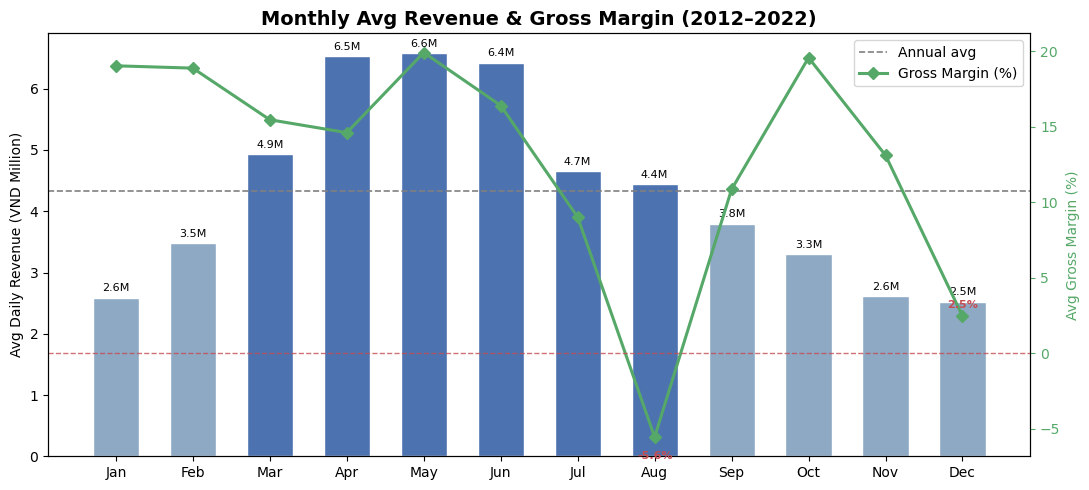

In [7]:
# Chart 6: Monthly Revenue Seasonality & Gross Margin
monthly_avg = (sales.groupby('month')
               .agg(avg_rev=('Revenue', 'mean'),
                    avg_margin=('margin', 'mean'))
               .reset_index())
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = ['#4C72B0' if v >= monthly_avg['avg_rev'].mean() else '#8DA9C4'
              for v in monthly_avg['avg_rev']]
bars = ax.bar(month_labels, monthly_avg['avg_rev'] / 1e6,
              color=bar_colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='{:.1f}M', padding=3, fontsize=8)
ax.set_title('Monthly Avg Revenue & Gross Margin (2012–2022)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Daily Revenue (VND Million)')
ax.axhline(monthly_avg['avg_rev'].mean() / 1e6, color='gray',
           linestyle='--', lw=1.2, label='Annual avg')

ax2 = ax.twinx()
ax2.plot(month_labels, monthly_avg['avg_margin'],
         color='#55A868', lw=2.2, marker='D', markersize=6, label='Gross Margin (%)')
ax2.axhline(0, color='#C44E52', lw=1, linestyle='--', alpha=0.8)
ax2.set_ylabel('Avg Gross Margin (%)', color='#55A868')
ax2.tick_params(axis='y', colors='#55A868')

for i, (m, mg) in enumerate(zip(month_labels, monthly_avg['avg_margin'])):
    if mg < 5:
        ax2.annotate(f'{mg:.1f}%', xy=(i, mg),
            xytext=(0, -16 if mg < 0 else 6),
            textcoords='offset points',
            ha='center', fontsize=8, color='#C44E52', fontweight='bold')

lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, loc='upper right')
plt.tight_layout()
plt.show()


**Overview:** Biểu đồ kết hợp cột (doanh thu trung bình theo tháng) và đường (gross margin %) thể hiện tính mùa vụ của doanh thu và hiệu quả lợi nhuận theo từng tháng trong năm.

**Descriptive - What happened?**
Doanh thu phân bổ rõ rệt theo mùa: tháng 4–5 đạt đỉnh (6.5–6.6M VND/ngày), cao gấp 2.6 lần so với tháng 12 (2.5M VND/ngày — thấp nhất). Quý 2 (tháng 4–6) chiếm khoảng 38% tổng doanh thu cả năm. Đặc biệt, tháng 8 có gross margin âm (−5.6%) và tháng 12 gần bằng 0 (2.5%) — doanh nghiệp đang bán hàng lỗ hoặc hòa vốn trong hai tháng này.

**Diagnostic - Why did it happen?**
Gross margin âm tháng 8 cho thấy đây là thời điểm xả hàng tồn kho mùa hè với chiết khấu sâu, hoặc chi phí vận hành (logistics, nhân sự) tăng mạnh hơn doanh thu. Tháng 12 — mùa lễ hội — thường là cao điểm bán lẻ nhưng margin chỉ 2.5%, cho thấy chi phí khuyến mãi và logistics cuối năm rất lớn. Tháng 10 có margin cao nhất (19.6%) dù doanh thu không cao — đây là tháng bán hàng hiệu quả nhất về lợi nhuận.

**Predictive - What is likely to happen?**
Mùa vụ rất ổn định qua 10 năm — Q2 sẽ tiếp tục là giai đoạn tạo ra phần lớn doanh thu. Tháng 8 và 12 nếu không điều chỉnh COGS/chi phí vận hành sẽ tiếp tục là gánh nặng lợi nhuận, đặc biệt khi quy mô tăng lên.

**Prescriptive - What should we do?**
- Kiểm tra ngay cấu trúc COGS tháng 8 và 12: ưu tiên tìm nhà cung cấp logistics giá tốt hơn cho 2 tháng này hoặc điều chỉnh chính sách giảm giá tối đa.
- Tập trung toàn bộ ngân sách marketing vào tháng 3–5 để khuếch đại mùa cao điểm — đây là giai đoạn ROI cao nhất.
- Thiết kế chương trình pre-order từ tháng 9 để chuyển một phần doanh thu tháng 10 về trước, san bằng mùa thấp điểm Q3.


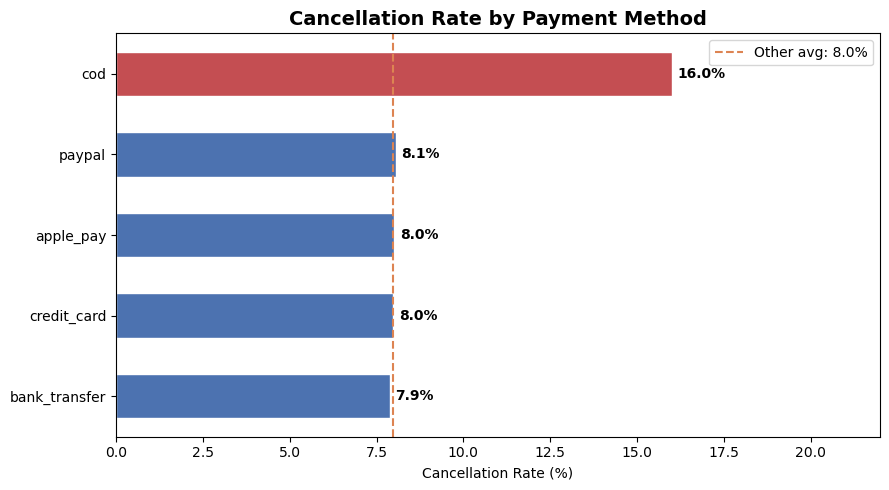

In [8]:
# Chart 7: Cancellation Rate by Payment Method
cancel_stats = (orders.groupby('payment_method')
                .apply(lambda x: pd.Series({
                    'total': len(x),
                    'cancelled': (x['order_status'] == 'cancelled').sum(),
                    'cancel_rate': (x['order_status'] == 'cancelled').mean() * 100
                })).reset_index()
                .sort_values('cancel_rate', ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#C44E52' if pm == 'cod' else '#4C72B0'
          for pm in cancel_stats['payment_method']]
bars = ax.barh(cancel_stats['payment_method'], cancel_stats['cancel_rate'],
               color=colors, edgecolor='white', height=0.55)
ax.bar_label(bars, fmt='{:.1f}%', padding=4, fontsize=10, fontweight='bold')

other_avg = cancel_stats[cancel_stats['payment_method'] != 'cod']['cancel_rate'].mean()
ax.axvline(other_avg, color='#DD8452', linestyle='--', lw=1.5,
           label=f'Other avg: {other_avg:.1f}%')

ax.set_title('Cancellation Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_xlim(0, 22)
ax.legend()
plt.tight_layout()
plt.show()


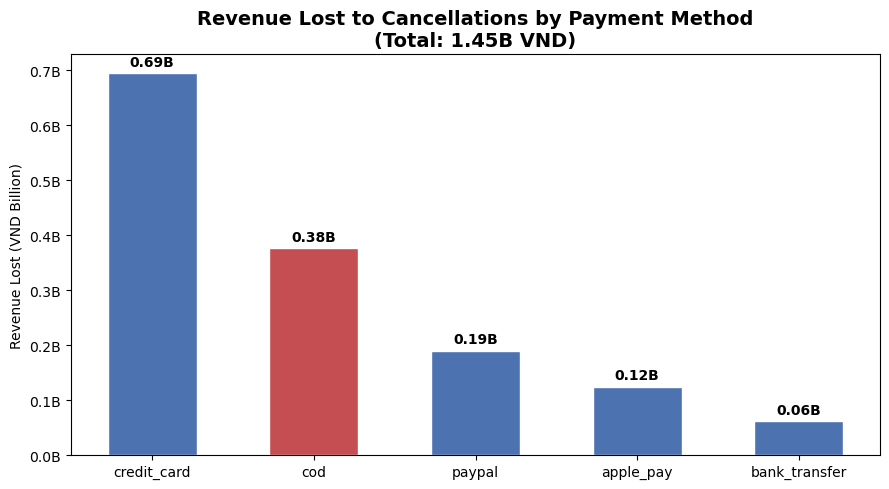

In [9]:
# Chart 8: Revenue Lost to Cancellations by Payment Method
order_value = (order_items.groupby('order_id')['line_rev']
               .sum().reset_index(name='order_value'))
orders_val  = orders.merge(order_value, on='order_id', how='left')
rev_lost = (orders_val[orders_val['order_status'] == 'cancelled']
            .groupby('payment_method')['order_value']
            .sum().reset_index(name='rev_lost')
            .sort_values('rev_lost', ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#C44E52' if pm == 'cod' else '#4C72B0'
          for pm in rev_lost['payment_method']]
bars = ax.bar(rev_lost['payment_method'], rev_lost['rev_lost'] / 1e9,
              color=colors, edgecolor='white', width=0.55)
ax.bar_label(bars, fmt='{:.2f}B', padding=3, fontsize=10, fontweight='bold')

total_lost = rev_lost['rev_lost'].sum()
ax.set_title(f'Revenue Lost to Cancellations by Payment Method\n(Total: {total_lost/1e9:.2f}B VND)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue Lost (VND Billion)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
plt.tight_layout()
plt.show()


**Overview:** Hai biểu đồ kết hợp phân tích vấn đề hủy đơn theo phương thức thanh toán — Chart 3 đo tỷ lệ hủy (%), Chart 4 đo doanh thu bị mất thực tế (VND) — giúp định lượng rủi ro kinh doanh từ từng kênh thanh toán.

**Descriptive - What happened?**
COD có tỷ lệ hủy đơn 16.0% — cao gấp đôi tất cả phương thức còn lại (~8.0%). Về doanh thu mất do hủy đơn: credit_card lớn nhất tuyệt đối (0.69B VND) do volume đơn hàng cao nhất (356K đơn), nhưng COD mất 0.38B VND với chỉ 96K đơn — tức mỗi đơn COD bị hủy gây thiệt hại gấp đôi về tần suất so với credit_card. Tổng doanh thu mất toàn hệ thống: 1.47B VND.

**Diagnostic - Why did it happen?**
COD không yêu cầu cam kết tài chính trước — khách đặt hàng dễ dàng và hủy không cần lý do. Đây là đặc điểm cố hữu của phương thức thanh toán này, không phải lỗi vận hành. Credit_card có tỷ lệ hủy thấp (8%) dù volume cao nhất vì khách đã xác nhận thanh toán trước — họ có động lực nhận hàng.

**Predictive - What is likely to happen?**
Với tốc độ tăng trưởng đơn hàng, nếu tỷ lệ COD trong mix thanh toán giữ nguyên, doanh thu mất do hủy đơn sẽ tăng tuyến tính. Giảm COD cancel rate từ 16% về 10% (tiệm cận mức trung bình thị trường) có thể cứu lại ~57B VND/năm chỉ từ COD.

**Prescriptive - What should we do?**
- Yêu cầu đặt cọc 20–30% với đơn COD có giá trị > 500.000 VND — giảm rủi ro hủy mà không loại bỏ hoàn toàn tùy chọn này.
- Tặng voucher 50.000–100.000 VND cho khách chuyển từ COD sang prepaid method — chi phí khuyến mãi thấp hơn nhiều so với doanh thu mất.
- Giới hạn COD với khách có lịch sử hủy > 2 lần: xây dựng hệ thống credit score nội bộ dựa trên hành vi đặt hàng.


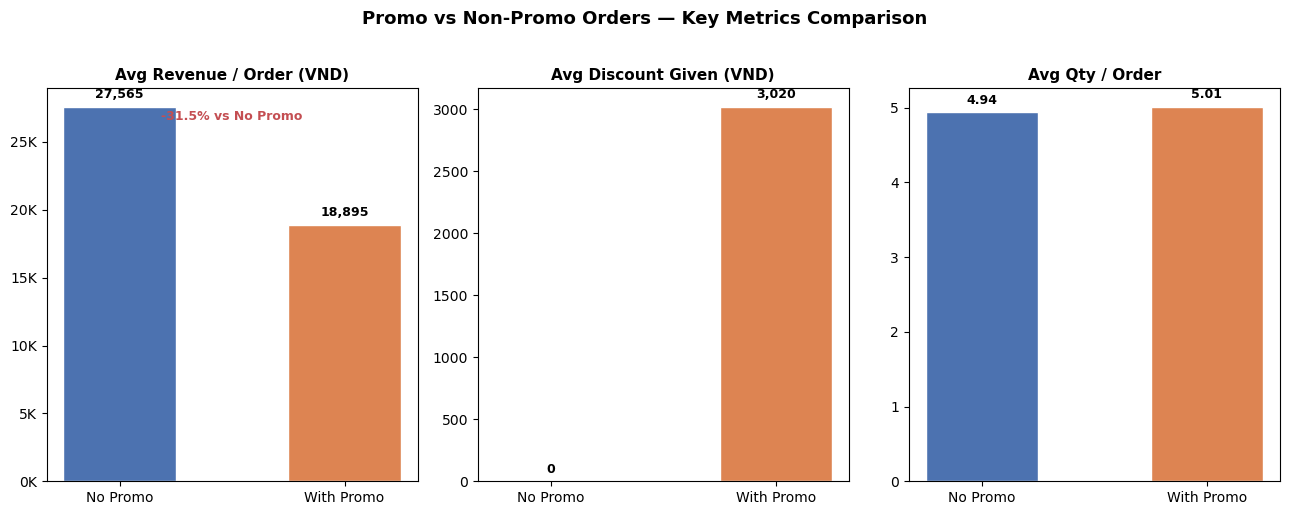

In [10]:
# Chart 9: Promo vs Non-Promo — Revenue per Order & Avg Discount
order_promo = (order_items.groupby('order_id')
               .agg(has_promo=('has_promo', 'max'),
                    total_rev=('line_rev', 'sum'),
                    total_discount=('discount_amount', 'sum'),
                    total_qty=('quantity', 'sum'))
               .reset_index())
order_promo = order_promo.merge(orders[['order_id','order_status']], on='order_id')

summary = (order_promo.groupby('has_promo')
           .agg(n_orders=('order_id','count'),
                avg_rev_per_order=('total_rev','mean'),
                avg_discount=('total_discount','mean'),
                avg_qty=('total_qty','mean'),
                cancel_rate=('order_status', lambda x: (x=='cancelled').mean()*100))
           .reset_index())
summary['label'] = summary['has_promo'].map({False: 'No Promo', True: 'With Promo'})

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

metrics = [
    ('avg_rev_per_order', 'Avg Revenue / Order (VND)', '{:,.0f}'),
    ('avg_discount',      'Avg Discount Given (VND)',  '{:,.0f}'),
    ('avg_qty',           'Avg Qty / Order',           '{:.2f}'),
]
palette = ['#4C72B0', '#DD8452']

for ax, (col, title, fmt) in zip(axes, metrics):
    vals = summary[col].values
    bars = ax.bar(summary['label'], vals, color=palette, edgecolor='white', width=0.5)
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals],
                 padding=4, fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('')
    if col == 'avg_rev_per_order':
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

pct_diff = (summary.loc[1,'avg_rev_per_order'] - summary.loc[0,'avg_rev_per_order'])            / summary.loc[0,'avg_rev_per_order'] * 100
axes[0].text(0.5, 0.92, f'{pct_diff:+.1f}% vs No Promo',
             transform=axes[0].transAxes, ha='center', fontsize=9,
             color='#C44E52', fontweight='bold')

plt.suptitle('Promo vs Non-Promo Orders — Key Metrics Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Overview:** Ba biểu đồ cột so sánh song song ba chỉ số quan trọng giữa đơn hàng có và không có khuyến mãi, giúp đánh giá hiệu quả thực sự của chương trình promo lên doanh thu, chi phí và hành vi mua hàng.

**Descriptive - What happened?**
Đơn hàng có promo tạo ra doanh thu trung bình **thấp hơn 31.5%** so với đơn không promo (18.895 VND vs 27.565 VND/đơn). Discount trung bình được cấp: 2.713 VND/đơn (với đơn không promo là 0). Số lượng sản phẩm/đơn gần như không khác biệt (5.01 vs 4.94 sản phẩm). Tỷ lệ hủy đơn của hai nhóm gần bằng nhau (~9.2%).

**Diagnostic - Why did it happen?**
Promo không kéo khách mua nhiều hơn (qty không tăng đáng kể) nhưng bào mòn giá trị đơn hàng nghiêm trọng (−31.5%). Điều này cho thấy các promo hiện tại là **dạng giảm giá thẳng trên sản phẩm**, không phải dạng "mua thêm để được giảm" (threshold-based). Khách hàng tận dụng promo để mua cùng lượng hàng với giá rẻ hơn — thay vì mua nhiều hơn để đạt ngưỡng ưu đãi.

**Predictive - What is likely to happen?**
Nếu tỷ lệ promo orders trong mix tiếp tục ở mức 38.6% (Q5), và avg revenue/order với promo thấp hơn 31.5% so với non-promo, doanh nghiệp đang hy sinh ~12% tổng revenue tiềm năng cho hoạt động khuyến mãi. Con số này sẽ tăng nếu chương trình promo mở rộng mà không thay đổi cơ chế.

**Prescriptive - What should we do?**
- Chuyển toàn bộ promo sang dạng **minimum order value**: thay vì "giảm 15% tất cả sản phẩm", áp dụng "giảm 15% khi mua từ 500.000 VND" — buộc khách tăng basket size để đủ điều kiện.
- Thí điểm A/B test: 50% traffic nhận promo kiểu cũ, 50% nhận promo threshold — đo avg order value và conversion rate sau 30 ngày.
- Giới hạn promo đồng thời (stackable_flag = 0) cho các category có margin thấp (GenZ, tháng 8, tháng 12) để bảo vệ lợi nhuận trong giai đoạn rủi ro.
